In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('homework_4.1.csv')
df

,Z,W,X,Y
0,0,-0.155644,-0.496971,0.282484
1,1,0.529539,2.284240,4.740596
2,1,0.910514,0.872232,3.449569
3,1,-0.705476,2.157260,3.002531
4,0,-0.590874,-0.386730,-1.848796
...,...,...,...,...
4995,0,-0.976289,0.482060,-0.830112
4996,0,0.677586,-0.580264,1.106948
4997,0,-0.829560,0.895967,-0.612659
4998,0,-1.126846,-0.178558,-2.882220


In [3]:
df['W'].duplicated().any()

np.False_

Task: Given data about an instrumental variable, find the effect. X is the treatment, W the confounder, Y the outcome, and Z the instrument. Use homework_4.1.csv. 

Personal notes:

Z (instrument) influences X (treatment) but has no effect on Y (outcome) except through the treatment

I need to calculate the following and take average of W for it

(Y(Z=1, W) - Y(Z=0, W)) / (X(Z=1, W) - X(Z=0, W))

Since we don't have any duplicate W's, we need to use averages instead. We don't need to know W

Q1. Did you need to know W to do this? 

A. No

B. Yes

A1. A (No)

Q2. As in the explanation, try averaging the **Y** difference and **X** difference (over **W** and **Z**) in two ways: 

1. Subtract the average **Y** value for **Z equals 1**and **Z equals 0**. Subtract the average **X**value for **Z equals 1** and **Z equals 0**. Divide the two. 
2. Find the average **Y** value for **Z equals 1**and **Z equals 0** for a narrow range of **W**. Find the average **X**value for **Z equals 1** and **Z equals 0** for the same narrow range of **W**. Take the ratio to find the effect. Then average this over all the ranges of **W**.


For the first item, the effect is closest to: 

A: 1.5

B: 2

C: 1

D: 0.5 

In [4]:
z1 = df[df['Z'] == 1]
z0 =  df[df['Z'] == 0]

In [5]:
y_avg_z1 = z1['Y'].mean()
y_avg_z0 = z0['Y'].mean()
y_avg_z1, y_avg_z0

(np.float64(1.5334744841544254), np.float64(-0.057370742020927984))

In [6]:
x_avg_z1 = z1['X'].mean()
x_avg_z0 = z0['X'].mean()
x_avg_z1, x_avg_z0

(np.float64(1.0091964255717258), np.float64(-0.009362563574908741))

In [7]:
y_avg_z1 - y_avg_z0

np.float64(1.5908452261753534)

In [8]:
x_avg_z1 - x_avg_z0

np.float64(1.0185589891466347)

In [9]:
(y_avg_z1 - y_avg_z0) / (x_avg_z1 - x_avg_z0)

np.float64(1.5618587073765746)

A2. 1.5

2. Find the average **Y** value for **Z equals 1**and **Z equals 0** for a narrow range of **W**. Find the average **X**value for **Z equals 1** and **Z equals 0** for the same narrow range of **W**. Take the ratio to find the effect. Then average this over all the ranges of **W**.


In [10]:
df.describe()

,Z,W,X,Y
count,5000.000000,5000.000000,5000.000000,5000.000000
mean,0.501400,-0.009934,0.501343,0.740279
std,0.500048,0.997779,1.127010,2.225679
min,0.000000,-3.303406,-3.404084,-7.032995
25%,0.000000,-0.697551,-0.272628,-0.787994
50%,1.000000,-0.032234,0.516908,0.718374
75%,1.000000,0.647618,1.254057,2.240705
max,1.000000,4.783257,4.693866,10.081975


<Axes: >

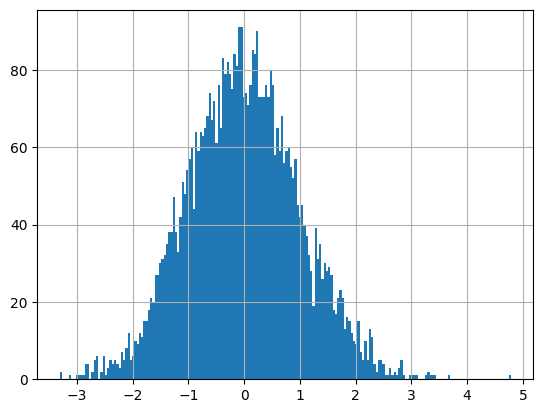

In [22]:
df['W'].hist(bins=200)

In [ ]:
# Note I tried pd.cut initially but the resulting effect was wrong. I think it is due to qcut makes equally sized ranges. 
# When we calculate the effect by taking mean there could have been an issue with small ranges having the same effect as large ranges on the result
# I picked q as 200 pretty arbitrarily based on the histogram by looking at different bin counts
df["W_range"] = pd.qcut(df["W"], q=200, labels=False) # No labels so that it doesn't becomne a tuple in the df. When we group by it goes by value so no label is needed

ratio_effects = []

for _, w_range_group in df.groupby("W_range"):
    w_range_z1 = w_range_group[w_range_group["Z"] == 1]
    w_range_z0 = w_range_group[w_range_group["Z"] == 0]

    # Find the average Y value for Z=1 and Z=0 for a narrow range of W.
    mean_y_z1 = w_range_z1["Y"].mean()
    mean_y_z0 = w_range_z0["Y"].mean()

    # Find the average X value for Z=1 and Z=0 for the same narrow range of W.
    mean_x_z1 = w_range_z1["X"].mean()
    mean_x_z0 = w_range_z0["X"].mean()

    # Take ratio to find the effect
    ratio_effects.append(
        (mean_y_z1 - mean_y_z0) / (mean_x_z1 - mean_x_z0)
    )

# Average this over all the ranges of W.
mean_ratio_effect = np.mean(ratio_effects)
mean_ratio_effect

np.float64(1.5204013947266082)

In [37]:
df

,Z,W,X,Y,W_bin
0,0,-0.155644,-0.496971,0.282484,89
1,1,0.529539,2.284240,4.740596,142
2,1,0.910514,0.872232,3.449569,165
3,1,-0.705476,2.157260,3.002531,49
4,0,-0.590874,-0.386730,-1.848796,57
...,...,...,...,...,...
4995,0,-0.976289,0.482060,-0.830112,33
4996,0,0.677586,-0.580264,1.106948,152
4997,0,-0.829560,0.895967,-0.612659,41
4998,0,-1.126846,-0.178558,-2.882220,25
